In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from glob import glob
import os
from datetime import datetime
import matplotlib
import matplotlib.patches as patches
import xgboost as xgb

matplotlib.rcParams.update({'errorbar.capsize': 4})

In [8]:
filtAv = [438, 472, 549, 575, 586, 605, 631, 661, 676, 692]
filtUn = np.array([28, 35, 21, 35, 26, 22, 28, 26, 29, 47]) / 2
filtQE = np.array([0.52654585, 0.61510198, 0.67157561, 0.70026282, 0.71884383, 0.7279477, 0.72530424, 0.71414267, 0.68976776, 0.6438945])

ROOTPATH = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/'

In [18]:
def prepare_spectrum(files, roi):
    nfilt = len(files)
    
    imdark = io.imread(files[-1]).astype(np.int64)
    # img = io.imread(files[0]).astype(np.int64)
    imroi = imdark[roi[0]:roi[1], roi[2]:roi[3]]
    roiSize = imroi.shape[0] * imroi.shape[1]
    offset = 100 * roiSize

    avInt = []
    unInt = []
    for i in range(nfilt-2):
        im = io.imread(files[i]).astype(np.int64)
        img = im - imdark
        imroi = img[roi[0]:roi[1], roi[2]:roi[3]]
        intPx = (imroi.sum() - offset) / roiSize
        avInt.append(intPx)
        
        unPx = np.sqrt((imroi**2).sum()) / roiSize
        unInt.append(unPx)

    avInt = np.array(avInt)
    unInt = np.array(unInt)
    cntQe = avInt / filtQE
    # cntQe /= (filtUn*2)

    unInt /= filtQE
    # unInt /= (filtUn*2)


    return cntQe, unInt

def plot_spectrum(path, roi, label = None):
    if label == None:
        label = os.path.split(path)[1]
    files = glob(path+'/*.tif')
    files.sort()
    ct, unt = prepare_spectrum(files, roi)

    plt.errorbar(x = filtAv, xerr=filtUn, y = ct/(filtUn*2), yerr=unt/(filtUn*2), fmt='o-', label=label)

    plt.gca().set(xlabel='$\lambda$ (nm)', ylabel='cnts/px/$\lambda$')
    plt.legend()
    return ct, unt

# Mitutoyo objective, December 12th 2024

## Spectra diode

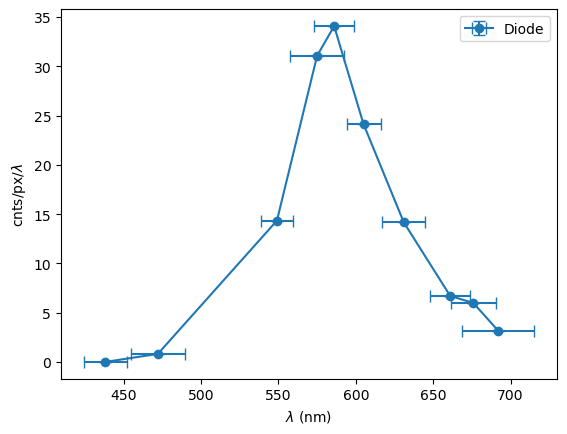

In [10]:
path = ROOTPATH+'sets/08-12-24/Rhodamine-B 50 µM/1'
roi = [1, 2024, 1, 2024]
files = glob(path+'/*.tif')
files.sort()
c, un = prepare_spectrum(files, roi)
c -= c.min()

plt.errorbar(x = filtAv, xerr=filtUn, y = c/(filtUn*2), yerr=un/(filtUn*2), fmt='o-', label='Diode')

plt.gca().set(xlabel='$\lambda$ (nm)', ylabel='cnts/px/$\lambda$')
plt.legend()

## Spectra TOptica + diode

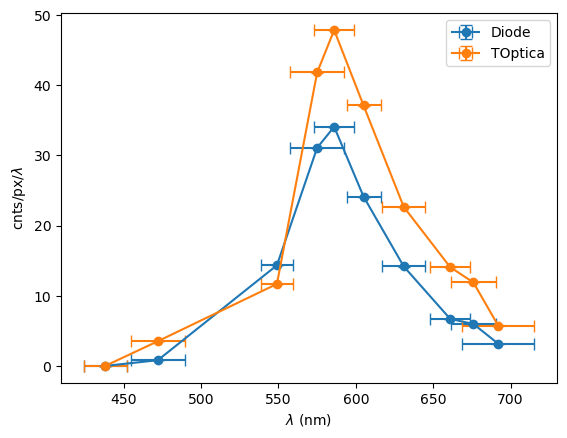

In [11]:
path = ROOTPATH+'sets/08-12-24/Rhodamine-B 50 µM/2'
roi = [1, 2024, 1, 2024]
files = glob(path+'/*.tif')
files.sort()
ct, unt = prepare_spectrum(files, roi)

ct -= ct.min()
ct *= 4.4
unt *= 4.4

plt.errorbar(x = filtAv, xerr=filtUn, y = c/(filtUn*2), yerr=un/(filtUn*2), fmt='o-', label='Diode')
plt.errorbar(x = filtAv, xerr=filtUn, y = ct/(filtUn*2), yerr=unt/(filtUn*2), fmt='o-', label='TOptica')

plt.gca().set(xlabel='$\lambda$ (nm)', ylabel='cnts/px/$\lambda$')
plt.legend()

# Repeat measurement, January 30th 2025

Improved light insulation, alignment

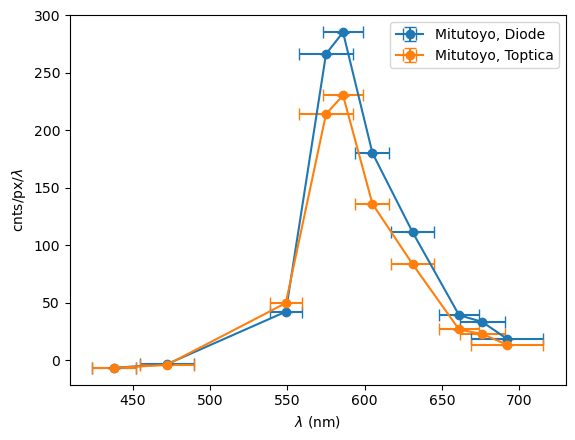

In [76]:
roi = [1, 2024, 1, 2024]
path_diode = ROOTPATH + 'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/1'
path_topt = ROOTPATH + 'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/2'


plot_spectrum(path_diode, roi, label='Mitutoyo, Diode')
plot_spectrum(path_topt, roi, label='Mitutoyo, Toptica');

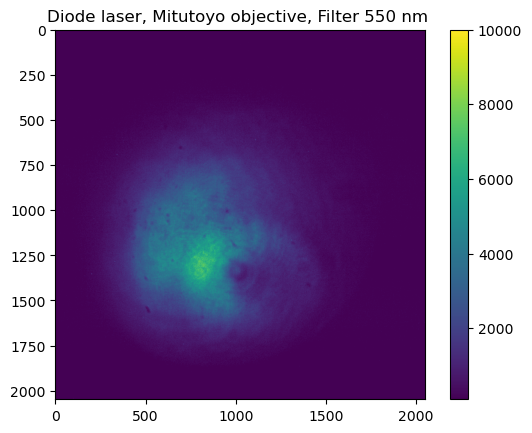

In [70]:
file = ROOTPATH+'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/1/Center-549nm_Width-21nm_15-03-27.tif'
filebg = ROOTPATH+'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/1/Dark_Blind_15-03-27.tif'

im = io.imread(file).astype(np.int64)
imbg = io.imread(filebg).astype(np.int64)
im -= imbg
plt.imshow(im, clim=(100, 1e4))
plt.title('Diode laser, Mitutoyo objective, Filter 550 nm ')
plt.colorbar()

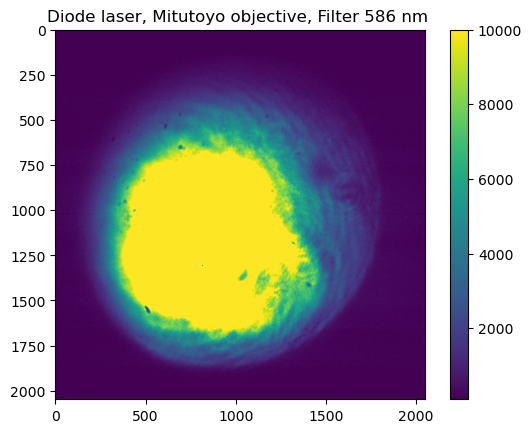

In [71]:
file = ROOTPATH+'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/1/Center-586nm_Width-26nm_15-03-27.tif'
filebg = ROOTPATH+'sets/30-01-25/Rhodamine-B 50 µM, Mitutoyo/1/Dark_Blind_15-03-27.tif'

im = io.imread(file).astype(np.int64)
imbg = io.imread(filebg).astype(np.int64)
im -= imbg
plt.imshow(im, clim=(100, 1e4))
plt.title('Diode laser, Mitutoyo objective, Filter 586 nm ')
plt.colorbar()

# Spectra Nikon NA 0.95

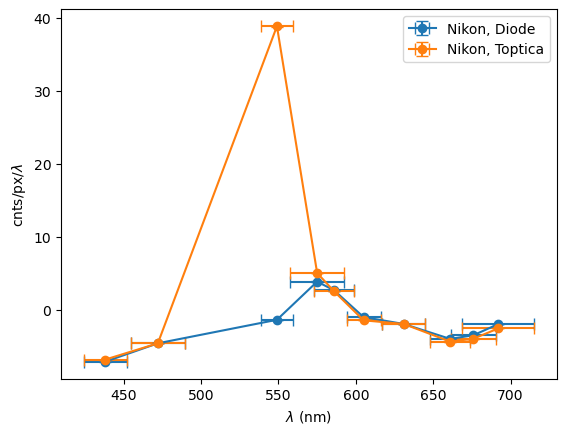

In [49]:
roi = [1, 2024, 1, 2024]
path_topt = ROOTPATH + 'sets/09-02-25/Rhodamine-B 50 µM/1'
path_diode = ROOTPATH + 'sets/09-02-25/Rhodamine-B 50 µM/2'

plot_spectrum(path_diode, roi, label='Nikon, Diode')
plot_spectrum(path_topt, roi, label='Nikon, Toptica');

## Plot selected images

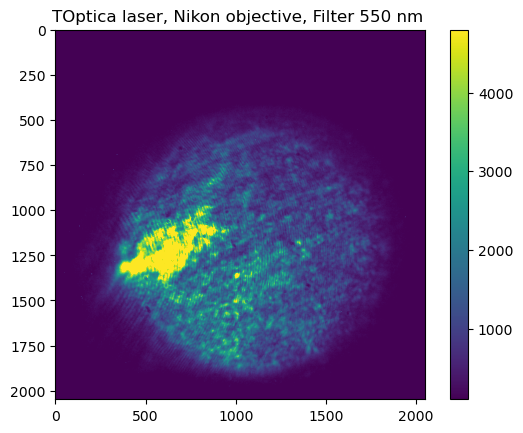

In [73]:
file = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/1/Center-549nm_Width-21nm_14-01-07.tif'
filebg = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/1/Dark_Blind_14-01-07.tif'

im = io.imread(file).astype(np.int64)
imbg = io.imread(filebg).astype(np.int64)
im -= imbg
plt.imshow(im, clim=(100, 48e2))
plt.title('TOptica laser, Nikon objective, Filter 550 nm ')
plt.colorbar()

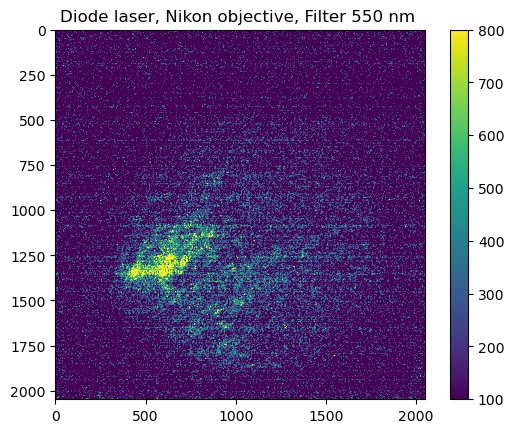

In [74]:
file = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/2/Center-549nm_Width-21nm_14-25-51.tif'
filebg = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/2/Dark_Blind_14-25-51.tif'

im = io.imread(file).astype(np.int64)
imbg = io.imread(filebg).astype(np.int64)
im -= imbg
plt.imshow(im, clim=(100, 8e2))
plt.title('Diode laser, Nikon objective, Filter 550 nm ')
plt.colorbar()

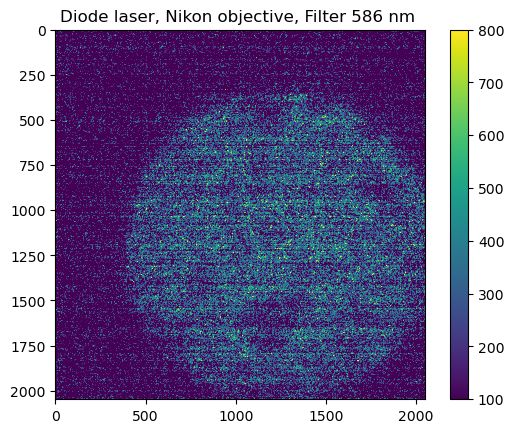

In [75]:
file = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/2/Center-586nm_Width-26nm_14-25-51.tif'
filebg = ROOTPATH+'sets/09-02-25/Rhodamine-B 50 µM, Nikon/2/Dark_Blind_14-25-51.tif'

im = io.imread(file).astype(np.int64)
imbg = io.imread(filebg).astype(np.int64)
im -= imbg
plt.imshow(im, clim=(100, 8e2))
plt.title('Diode laser, Nikon objective, Filter 586 nm ')
plt.colorbar()